**uninteractive example of `hifast.sw` and `hifast.ripple.sw_fft`**

author: Xu Chen, 2023/3/9， xuchen@nao.cas.cn


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hifast.ripple.util import *
from hifast.ripple.sw_fft import *
from copy import deepcopy

In [3]:
# 这里是已经去过基线的-bld.hdf5文件，如果标记了RFI，使用含-rfi.hdf5的文件
subname = '/data/inspur_disk01/userdir/xuc/FAST/M33/new_21/OTF_h/rfi/M33_OTF_1_MultiBeamOTF-M01_W-20210731-specs_T-bld-rfi.hdf5'
sub = Read_hdf5(Args(subname))

outdir: /data/inspur_disk01/userdir/xuc/FAST/M33/new_21/OTF_h/rfi


# example polar xx

以偏振xx为例去除驻波

In [4]:
data = sub.get_data(polar='xx')
freq = sub.freq
is_on = sub.fs['is_on'][:]
is_rfi =time_rfi = sub.fs['is_rfi'][:]

# RFI

这个示例文件里没有时域RFI，如果要测试参数，可以使用另一个RFI botebook调节参数：

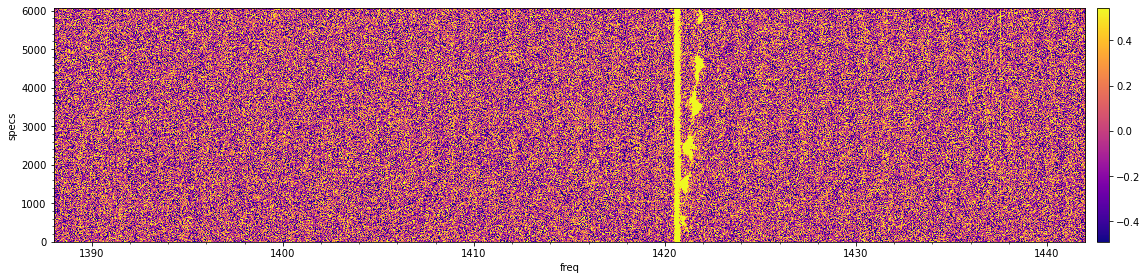

In [5]:
sub.plot_waterfall(data,per_vmin_max=.90,figsize=(18,4),cmap = 'plasma')

# RMS

目前rms可以手动指定选一个没有信号和干扰范围计算RMS。例如```--rms_frange 1410 1415```

如果不指定会自动寻找一个5MHz长没有干扰的区域，同时弹出一个info

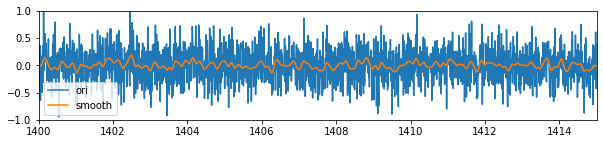

In [6]:
%matplotlib inline
spec = deepcopy(data[0,:])
def test_gauss(freq,sigma):
    from hifast.utils.misc import smooth1d
    sm = smooth1d(spec,method='gaussian',sigma=sigma)
    return sm

fig,ax = plt.subplots(figsize=(10,2))
plt.plot(freq,spec,label = 'ori')
plt.plot(freq, test_gauss(freq, sigma=6),label='smooth')
plt.legend()
plt.xlim(1400,1415)
plt.ylim(-1,1)
plt.show()

# MW range
有MW的区域，下面会被强制替代为驻波。例如下图的判断，如果输入了```--mw_frange 1420.3,1420.8```，那么MW将都被替代。注意过长将影响对驻波估计的效果，所以也可以不输入(None). 默认```[0,0]```

(1420.0, 1423.0)

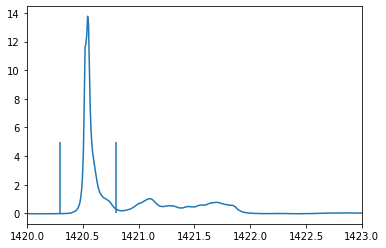

In [7]:
mw_frange = (1420.3,1420.8)
%matplotlib inline
plt.plot(freq,np.mean(data,axis = 0))
plt.vlines(mw_frange,ymin=0,ymax = 5)
plt.xlim(1420.0,1423)

# Replace RFI or strong sources

这里'near ripple'使用高流量处附近的驻波替代源或RFI。例如
* `--times_thr`:大于RMS这么多倍的会被置为噪声(不平滑)
* `--times_s_thr`:大于RMS这么多倍的会被替代(第一次迭代)
* `--times_s_thr2`:大于RMS这么多倍的会被替代(第二次迭代)
* `--rfi_width_lim`: 要替换的rfi/源，频率上的宽度应该大于一阈值(通道数)
* `--ext_sec`: (接上面的)并向两边扩展通道数
* `--ext_freq`: 先扩展边缘(MHz)，再寻找强流量两边的最低点，先使用左/右边的一段更干净一点的代替强流量处，默认1.3即可


In [8]:
def repalce_near_single(tn, freq, time_rfi, mw_use=None, times_s_thr=None,
                        times_s_thr2=None,times_thr=None, rms_sigma=None,ext_freq=None,
                        rms_frange=None, rfi_width_lim=None, ext_sec=None, 
                        sm1 = None, sm2 = None,  sm3 = None,
                       fill = 'original', shift = 0, save_is_excluded = False,ex_step=4):
    """
    replace mw, rfi or others by near ripple section

    times_thr:above * times of rms will be lowered
    ext_freq: extend freq range to replace (mhz)
    rfi_width_lim:rfi should contain more channels than limit
    ext_sec: extend channel number of start and end of each section
    """
    global fdelta
    fdelta = freq[1]-freq[0]

    ext = int(np.around(ext_freq / fdelta))

    from hifast.ripple.markRFI import real_std, real_rms, std, rms
    save_is_excluded = True if save_is_excluded and (times_s_thr2 is not None) else False
    if mw_use is None:
        mw_use = np.full(freq.shape, False)

#     newspec = np.full(data.shape[0], np.nan)
    MAX = np.nanmax(data)*20
    #################
    spec = deepcopy(data[tn, :])
    include = mw_use #| time_rfi[tn]
    if np.sum(include) > 0:
        spec[include] = MAX * 20   
    if times_s_thr2 is None: times_s_thr2 = times_s_thr
    RMS = rms(sm2, freq, rms_vrange=rms_frange)
    thr_s = RMS*times_s_thr2
    exceed_use = (np.abs(sm2) > thr_s) | time_rfi[tn]
    if save_is_excluded:
        save_ex_step = int(np.around(ex_step / fdelta))
        #is_excluded = save_rep_2sides(sm2, freq, exceed_use, rfi_width_lim, ext_sec, ext, thr_s, freq_d, freq_u)
        is_excluded = save_rep_fixed(sm2, freq, exceed_use, rfi_width_lim, 
                                             ext_sec, save_ex_step, freq_d,freq_u)
        
        is_excluded[:freq_d] = False
        is_excluded[freq_u:] = False
    else:
        is_excluded = None
    
    if sm3 is not None:
        restrict_use = (np.abs(sm3) > thr_s) | time_rfi[tn]
    else:
        restrict_use = np.full(freq.shape,True)
    STD = real_std(spec, freq, sigma = rms_sigma, vrange = rms_frange)
    newspec, rep_from, rep_to = replace_spec(tn, spec, freq, exceed_use, restrict_use, rfi_width_lim, ext_sec,
                           ext, STD, MAX, sm = sm1,test = True,fill = fill, shift = shift)

    RMS = real_rms(spec, freq, sigma=rms_sigma, rms_vrange=rms_frange)
    strange = np.where(np.abs(newspec) > times_thr * RMS)[0]
    newspec[strange] = np.random.normal(scale=RMS, size=len(strange))
    
    return newspec, rep_from, rep_to, is_excluded 

通过单条谱线尝试参数，划分被replace的范围.之前已经确定了rms_sigma=6,rms_frange=[1405,1410]，这里测试其他参数，使得不要替代过多的噪声而速度变慢。

# first iteration

第一次迭代。如果对弱源流量要求不高，可以不进行第二次迭代

首先,先进行第一次平滑，用于寻找需要替代的位置。使用了时间和频率两个方向，尽量保留弱源。对应`--s_method_t`,`--s_sifma_t`,`--s_method_freq`,`--s_sigma_freq`

In [9]:
import time
time_start = time.time()

sm_args = {}
sm_args['s_method_t'] = 'gaussian'
sm_args['s_sigma_t'] = 5
sm_args['s_method_freq'] = 'gaussian'
sm_args['s_sigma_freq'] = 3
sm_args['is_rfi'] = is_rfi
sm_args['is_on'] = is_on
data_find = do_smooth_onoff(data, **sm_args)

time_end = time.time()
print('Time cost = %fs' % (time_end - time_start))

Smoothing t ...
Smoothing freq ...
Smoothing t ...
Smoothing freq ...
Time cost = 3.191691s


第二次平滑，用于寻找驻波的波谷。如果不给定`--s_method_t_T`,`--s_sifma_t_T`,`--s_method_freq_T`,`--s_sigma_freq_T`,则使用与上一组相同的。

In [10]:
time_start = time.time()

sm_args = {}
sm_args['s_method_t'] = 'gaussian'
sm_args['s_sigma_t'] = 10
sm_args['s_method_freq'] = 'gaussian'
sm_args['s_sigma_freq'] = 5
sm_args['is_rfi'] = is_rfi
sm_args['is_on'] = is_on
data_trough = do_smooth_onoff(data, **sm_args)

time_end = time.time()
print('Time cost = %fs' % (time_end - time_start))

Smoothing t ...
Smoothing freq ...
Smoothing t ...
Smoothing freq ...
Time cost = 5.560081s


由于时间上的平滑可能扩大应该替代的区域，一旦`'s_method_t'!='none`且`restrict_bound = True`，将进行只有freq方向sigma为`rms_sigma`的第三次高斯平滑来限定替代区域。

对于小源，可以不使用这一步，`restrict_bound = False`由于时间上的平滑可能扩大应该替代的区域，一旦`'s_method_t'!='none`且`restrict_bound = True`，将进行只有freq方向sigma为`rms_sigma`的第三次高斯平滑来限定替代区域。也可以跳过这里

In [11]:
sm_args = {}
sm_args['s_method_freq'] = 'gaussian'
sm_args['s_sigma_freq'] = 6
data_res = do_smooth_onoff(data, **sm_args)

Smoothing freq ...


可以分别尝试使用`mw_frange`与否的效果，**理论上不给MW范围限制更准**

mw_use = (freq > mw_frange[0])&(freq < mw_frange[1])

In [12]:
mw_use = np.full(freq.shape,False)

In [13]:
np.where(is_on)

(array([   4,    5,    6,    7,  604,  605,  606,  607, 1204, 1205, 1206,
        1207, 1804, 1805, 1806, 1807, 2404, 2405, 2406, 2407, 3004, 3005,
        3006, 3007, 3604, 3605, 3606, 3607, 4204, 4205, 4206, 4207, 4804,
        4805, 4806, 4807, 5404, 5405, 5406, 5407, 6004, 6005, 6006, 6007]),)

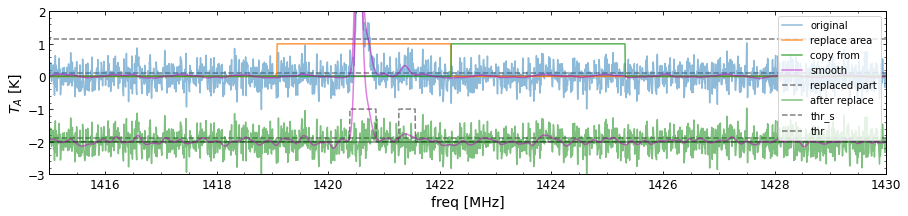

In [17]:
tn = 2000
spec = deepcopy(data[tn,:])
sm1 = data_trough[tn]
sm2 = data_find[tn]
sm3 = data_res[tn]
from hifast.utils.misc import smooth1d
args = {}
args['times_thr'] = 4
args['times_s_thr'] = 3
args['rfi_width_lim'] = 20
args['ext_sec'] = 20
args['ext_freq'] = 1.3
args['rms_sigma'] = 6
args['rms_frange'] = [1405,1410]

newspec, rep_from, rep_to, _ = repalce_near_single(tn, freq, is_rfi, mw_use,
                                                sm1 = sm1, sm2 =sm2, sm3 = sm3, **args)
difuse = ((spec - newspec)!=0)

fig = plt.figure(figsize=(15,3))
ax = fig.add_subplot(111)
ax.hlines(y=[0,-2],xmax=freq[-1],xmin=freq[0],color='k',alpha=.5)
ax.plot(freq,spec,label='original',alpha = .5)
# ax.plot(freq,is_rfi[tn]*1.1,'r--',label='rfi',alpha = .5)
ax.plot(freq,rep_to,alpha=.8,label = 'replace area')
ax.plot(freq,rep_from,alpha=.8,label =  'copy from')
ax.plot(freq,sm1,'m',alpha=.5,label='smooth')
ax.plot(freq,difuse - 2,'k--',label =  'replaced part',alpha=.5,)
ax.plot(freq,newspec - 2,'g',alpha=.5,label =  'after replace')
ax.plot(freq,sm3 - 2,'m',alpha=.5)
from hifast.ripple.markRFI import real_rms, rms
RMS = rms(sm1,freq,rms_vrange=args['rms_frange'])
thr_s = RMS*args['times_s_thr']
RMS = rms(sm2,freq,rms_vrange=args['rms_frange'])
thr_s2 = RMS*args['times_s_thr']
ax.hlines(y=[thr_s,thr_s2-2],xmax=freq[-1],xmin=freq[0],color='k', label = 'thr_s',linestyle='dashed',alpha=.5)

RMS = real_rms(spec,freq,sigma=args['rms_sigma'],rms_vrange=args['rms_frange'])
thr = RMS*args['times_thr']
ax.hlines(y=[thr],xmax=freq[-1],xmin=freq[0],color='k',label = 'thr', linestyle='dashed',alpha=.5)
ax.legend()

line_set(ax,xlabel='freq [MHz]',ylabel='$T_A$ [K]',xlim=[1415,1430],ylim=[-3,2],
         legend=False,title=None,)

## replace
前面确定好了参数，现在处理所有谱线

In [18]:
rep_args = {}
rep_args['rms_sigma'] = 6
rep_args['rms_frange'] = [1405, 1410]
rep_args['times_thr'] = 4
rep_args['times_s_thr'] = 3
# rep_args['times_s_thr2'] = 2 # 第二次迭代参数在第一次不使用
rep_args['rfi_width_lim'] = 20
rep_args['ext_sec'] = 20
rep_args['ext_freq'] = 1.3
# rep_args['mw_frange'] = mw_frange

In [19]:
data_rep, is_excluded = replace_rfi(data, freq, time_rfi=is_rfi, method='near_ripple',save_is_excluded = False,
                                 data_find = data_find, data_trough = data_trough, data_restrict = data_res, **rep_args)

INFO: Replace RFI with near_ripple method ... [hifast.ripple.sw_fft]


CPU 0: 100%|██████████| 6057/6057 [00:08<00:00, 688.17it/s]


`is_excluded`试图包含rfi和可能是源的部分，如果去驻波但不去基线(sw_nobld)，下一步再去基线(bld)，bld.py会读取其中的`is_excluded`，防止基线对信号的过拟合(但是此参数还需要更多测试)

`is_excluded`在第二次迭代中生成，所以这里是None

In [20]:
is_excluded 

array([None], dtype=object)

替代后瀑布图的效果

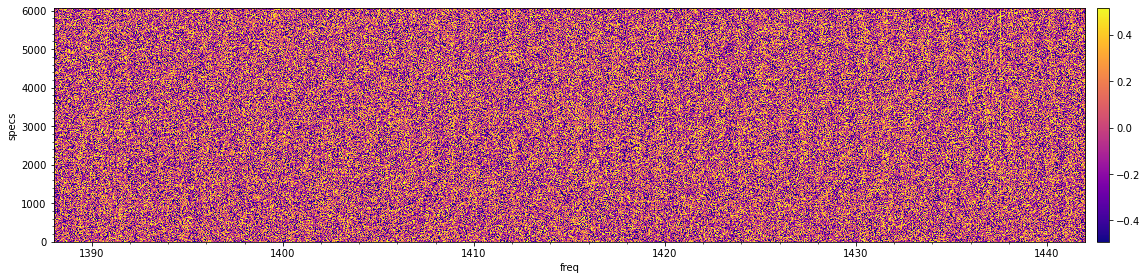

In [21]:
sub.plot_waterfall(data_rep,per_vmin_max=.90,figsize=(18,4),cmap = 'plasma')

# FFT remove 1MHz ripples

第一次迭代中的去驻波

* ```--sw_base```: 去除傅里叶空间的常数成分。如果基线整体偏离0, 此参数设为True可将谱线整体移动一个常数值。
* ```--sw_periods```: 去除的驻波成分。后可接多个字符。默认为```1mhz 0_04mhz```. 字符与对应的驻波周期为：
   * 字符: 驻波周期
   * 1mhz: 1.08mhz
   * 2mhz: 1.92mhz
   * 0_04mhz: 0.039 mhz

* ```--check_2mhz```: 若为True，如果输入Beam 6文件，将在``--sw_periods``中添加 ``2mhz``,如果输入的不是Beam 6文件，则删除 ``2mhz`` (如果存在)。所以除了2021年7月31日的数据，不要设为True
* ```--amp_thr_mean_factor```: 傅里叶空间的平均振幅大于阈值的模，会被识别为已知的几种驻波。这里输入的是中值的倍数。输入时noise off/on分别对应两个阈值
* ```--amp_thr_solo_factor```: 傅里叶空间的每一谱线的振幅大于阈值，会被选中为驻波一部分被去除。这里输入的是中值的倍数。输入时noise off/on分别对应两个阈值
* ```--chan_wide```: 距离驻波的模的中心左右各(2 * chann - 1)个通道数的模，作为驻波的一部分被选中. 用于`1mhz`和`2mhz`的驻波。默认为5
* ```--chan_narr```: 同上，窄一些的. 用于`0_04mhz`的驻波和 ``1mhz``的倍频。默认为2
* ```--choose_method```: 选择傅里叶空间中哪些模作为驻波的方法，'all'或者'interpolate'. 默认为'all'.

## Noise off

然后对data_rep进行FFT

In [22]:
divide_warning = np.seterr(divide='ignore')

In [23]:
from hifast.ripple.sw_fft import *
sw = SW_FFT(data_rep[~is_on], freq, 10)
sw.do_fft()
x = sw.x
amp_data = sw.amp
amp_mean = np.nanmean(amp_data,axis=0)
is_excluded_mean = np.all(is_rfi[~is_on], axis=1) # 严重RFI的谱线不会参与振幅平均

Text(0.5, 24.0, 't [$\\mu s$]')

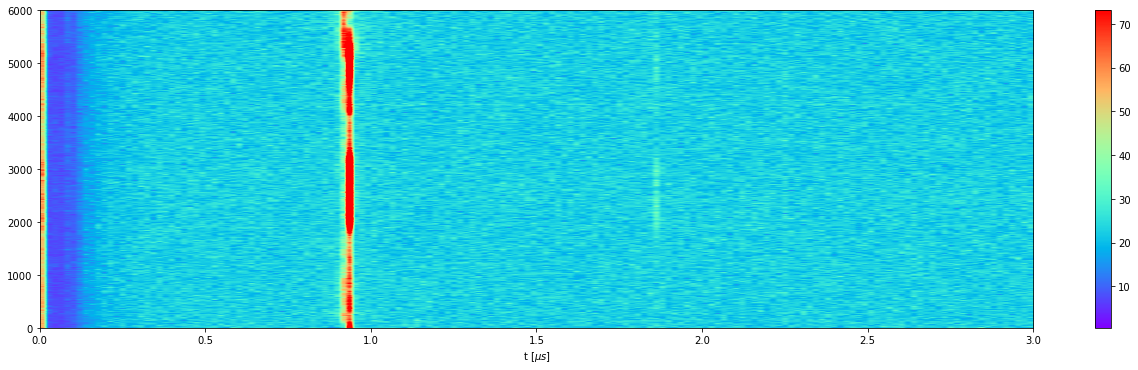

In [24]:
%matplotlib inline
plt.figure(figsize=(18,5))
vmin,vmax = percent_vminmax(amp_data,percent = .999)
plt.imshow(amp_data,origin='lower',aspect='auto',extent=(x[0],x[-1],0,amp_data.shape[0]),
        vmin=vmin,vmax=vmax,cmap='rainbow')

plt.tight_layout()
plt.colorbar()
plt.xlim(0,3)
plt.xlabel("t [$\mu s$]")

这里先给出Fourier空间中取模的成分范围，单位是通道数，分宽和窄两种

In [25]:
chan_wide=4 # 这是半宽
chan_narr=2
cw = 2 * chan_wide - 1
cn = 2 * chan_narr - 1
print(f"all_chan_wide = {cw}, all_chan_narrow = {cn}")

all_chan_wide = 7, all_chan_narrow = 3


内置的驻波种类，在$\mu$s轴上的大概范围，和选取的最大半通道数

In [26]:
sw_periods=['1mhz', '0_04mhz']
sw_conf = get_sw_conf(chan_wide, chan_narr)
sw_conf

{'1mhz': {'xlims': [[0.9, 0.95], [1.8, 1.9]], 'nchans': [4, 2]},
 '2mhz': {'xlims': [[0.5, 0.6]], 'nchans': [4]},
 '0_04mhz': {'xlims': [[25, 26]], 'nchans': [2]}}

通过平均所有振幅，决定该波束存在哪些驻波

In [27]:
def test_amp_mean(x,amp_thr_mean_factor):
    sw.gen_amp_thr_s(amp_thr_mean_factor,amp_thr_solo_factor=1.4,is_excluded_mean=is_excluded_mean)
    loc = []
    for key in sw_periods:
        sw.find_sw_loc(xlims=sw_conf[key]['xlims'])
        if np.sum(sw.bingo_list) >= 1:
            for b in range(len(sw.bingo_list)):
                if sw.bingo_list[b]:
                    loc += [sw.loc_list[b],]
    if len(loc)>0: loc = np.hstack((loc))
    select = np.full(x.shape,np.nan)
    
    select[loc] = 5 # modify plot height
    print("---------------------------------")
    return select

def test_amp_mean_line(x):
    amp_thr = sw.amp_thr_mean
    return np.full(len(x),amp_thr)

改变这里的amp_thr_mean_factor，选择的驻波数量会变化(print的变化在窗口里)

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
---------------------------------
find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
---------------------------------


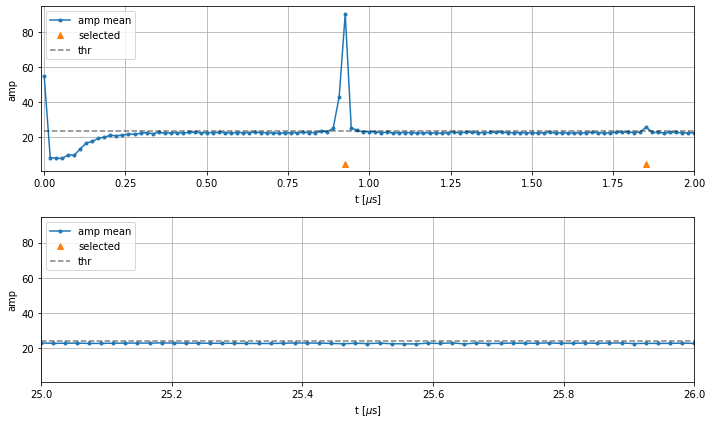

In [28]:
ylim=[0,15]
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
ax.set_xlim(-.01,2)
plt.plot(x,amp_mean,'.-', label = 'amp mean')
plt.plot(x,test_amp_mean(x,amp_thr_mean_factor=1.05),'^',
                     label='selected')
plt.plot(x,test_amp_mean_line(x,),'k--',
                     alpha=.5,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')

ax = fig.add_subplot(212) 
plt.plot(x,amp_mean,'.-', label = 'amp mean')
plt.plot(x,test_amp_mean(x,amp_thr_mean_factor=1.05),'^',
                     label='selected')
plt.plot(x,test_amp_mean_line(x,),'k--',
                     alpha=.5,label = 'thr')
ax.set_xlim(25,26)
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')
plt.tight_layout()

从平均的fourier模，可以看出明显的几种驻波，1mhz和它的倍频0.54mhz

同理，决定单条谱线适用的阈值倍数amp_thr_factor和取模通道数，chan_wide,chan_narr。这里测试off的谱线举例

In [29]:
def test_amp_solo(x,amp_thr_mean_factor,amp_thr_solo_factor,chan_wide,chan_narr):

    sw_conf1 = get_sw_conf(chan_wide, chan_narr)
    sw.gen_amp_thr_s(amp_thr_mean_factor,amp_thr_solo_factor,is_excluded_mean=is_excluded_mean)
    
    sw.is_use_sw_chan = np.full(x.shape,False)
    for key in sw_periods:
        sw.find_sw_loc(xlims=sw_conf1[key]['xlims'])
        sw.find_sw_chans(nchans=sw_conf1[key]['nchans'])
        is_use_sw_chan_amp = sw.is_use_sw_chan & (amp_data[tn] > sw.amp_thr_solo)
    
    select = np.zeros_like(x)   
    select[is_use_sw_chan_amp] = amp_data[tn][is_use_sw_chan_amp] 
    print("---------------------------------")
    return select


def test_amp_solo_line(x,):
    amp_thr = sw.amp_thr_solo
    return np.full(len(x),amp_thr)

dx = x[1] - x[0]

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
---------------------------------
find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
---------------------------------


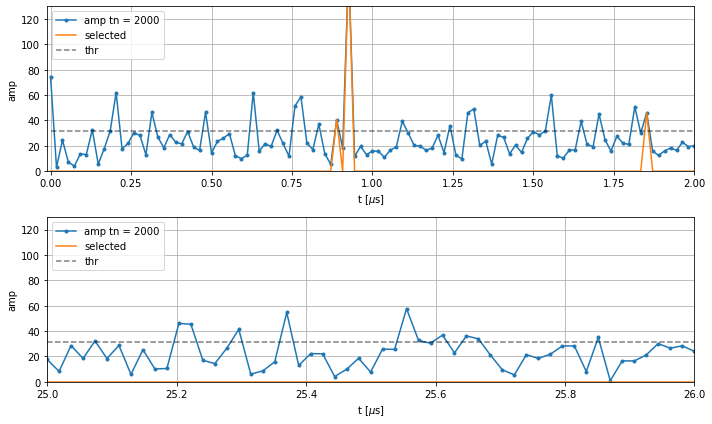

In [30]:
tn = 2000
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
xlim=[-.01,2];ylim=[0,130]
plt.plot(x,amp_data[tn],'.-', label = f'amp tn = {tn}')
plt.plot(x,test_amp_solo(x,amp_thr_mean_factor=1.05,amp_thr_solo_factor=1.4,chan_wide=4,chan_narr=2),
                     label='selected')
plt.plot(x,test_amp_solo_line(x),
         'k--',alpha=.5,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')

xlim=[25,26]
ax = fig.add_subplot(212) 
plt.plot(x,amp_data[tn],'.-', label = f'amp tn = {tn}')
plt.plot(x,test_amp_solo(x,amp_thr_mean_factor=1.05,amp_thr_solo_factor=1.4,chan_wide=4,chan_narr=2),
                     label='selected')
plt.plot(x,test_amp_solo_line(x),
         'k--',alpha=.5,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')
plt.tight_layout()

## Noise on

相同的调整参数方法

In [31]:
from hifast.ripple.sw_fft import *
sw = SW_FFT(data_rep[is_on], freq, 10)
sw.do_fft()
x = sw.x
amp_data = sw.amp
amp_mean = np.nanmean(amp_data,axis=0)
is_excluded_mean = np.all(is_rfi[is_on], axis=1) # 严重RFI的谱线不会参与振幅平均

Text(0.5, -3.0, 't [$\\mu s$]')

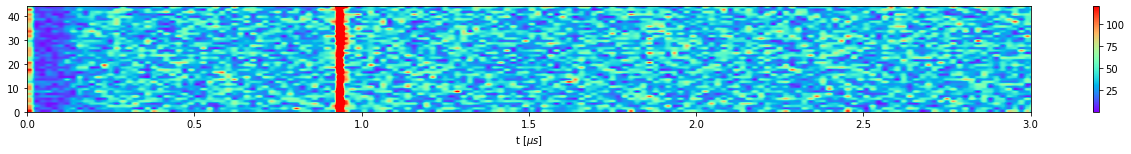

In [32]:
plt.figure(figsize=(18,2))
vmin,vmax = percent_vminmax(amp_data,percent = .999)
plt.imshow(amp_data,origin='lower',aspect='auto',extent=(x[0],x[-1],0,amp_data.shape[0]),
        vmin=vmin,vmax=vmax,cmap='rainbow')

plt.tight_layout()
plt.colorbar()
plt.xlim(0,3)
plt.xlabel("t [$\mu s$]")

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
---------------------------------
find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
---------------------------------


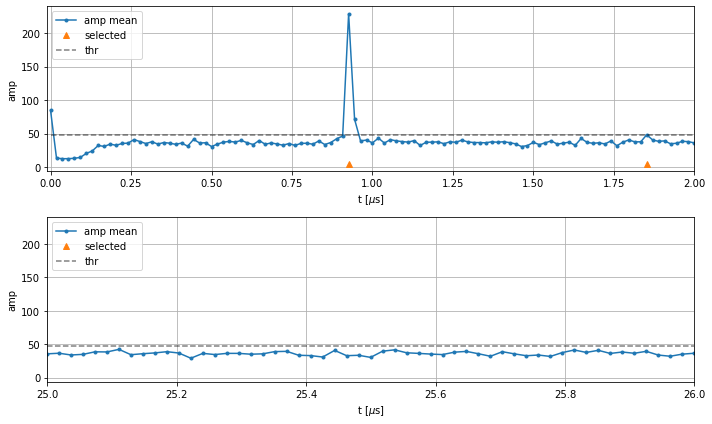

In [33]:
ylim=[0,15]
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
ax.set_xlim(-.01,2)
plt.plot(x,amp_mean,'.-', label = 'amp mean')
plt.plot(x,test_amp_mean(x,amp_thr_mean_factor=1.3),'^',
                     label='selected')
plt.plot(x,test_amp_mean_line(x,),'k--',
                     alpha=.5,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')

ax = fig.add_subplot(212) 
plt.plot(x,amp_mean,'.-', label = 'amp mean')
plt.plot(x,test_amp_mean(x,amp_thr_mean_factor=1.3),'^',
                     label='selected')
plt.plot(x,test_amp_mean_line(x,),'k--',
                     alpha=.5,label = 'thr')
ax.set_xlim(25,26)
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')
plt.tight_layout()

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
---------------------------------
find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
---------------------------------


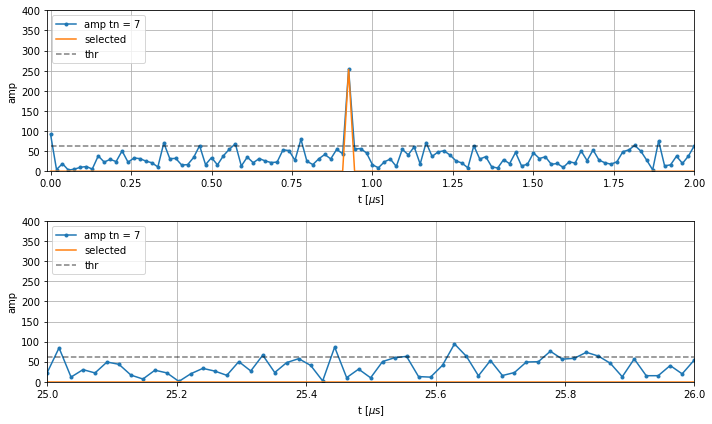

In [34]:
tn = 7
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
xlim=[-.01,2];ylim=[0,400]
plt.plot(x,amp_data[tn],'.-', label = f'amp tn = {tn}')
plt.plot(x,test_amp_solo(x,amp_thr_mean_factor=1.3,amp_thr_solo_factor=1.7,chan_wide=4,chan_narr=2),
                     label='selected')
plt.plot(x,test_amp_solo_line(x),
         'k--',alpha=.5,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')

xlim=[25,26]
ax = fig.add_subplot(212) 
plt.plot(x,amp_data[tn],'.-', label = f'amp tn = {tn}')
plt.plot(x,test_amp_solo(x,amp_thr_mean_factor=1.3,amp_thr_solo_factor=1.7,chan_wide=4,chan_narr=2),
                     label='selected')
plt.plot(x,test_amp_solo_line(x),
         'k--',alpha=.5,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')
plt.tight_layout()

对于测试数据，我选择了以下参数.`choose_method`有选择所有模'all'和线性插值'interpolate'两种方式，可以分别尝试效果。

## 现在使用完整的函数进行测试

In [35]:
fft_args_off = {}
fft_args_off['amp_thr_mean_factor'] = 1.05
fft_args_off['amp_thr_solo_factor'] = 1.4
fft_args_off['chan_wide'] = 4
fft_args_off['chan_narr'] = 2
fft_args_off['choose_method'] = 'all'
fft_args_off['sw_periods'] = ['1mhz',  '0_04mhz']
fft_args_off['sw_base'] = True
fft_args_off['is_excluded_mean'] = np.all(is_rfi[~is_on], axis=1)

sw_data_off = fit_sw_fft(data_rep[~is_on], freq, nproc=10,  **fft_args_off)

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100


In [36]:
fft_args_on = deepcopy(fft_args_off)
fft_args_on['amp_thr_mean_factor'] = 1.3
fft_args_on['amp_thr_solo_factor'] = 1.7
fft_args_on['is_excluded_mean'] = np.all(is_rfi[is_on], axis=1)
sw_data_on = fit_sw_fft(data_rep[is_on], freq, nproc=10,  **fft_args_on)

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100


In [37]:
sw_data = np.zeros_like(data) # 驻波
sw_data[is_on] = sw_data_on
sw_data[~is_on] = sw_data_off

rmsw_data = data - sw_data # remove standing waves之后的结果

下面可以画一下单条谱线的效果

In [38]:
from hifast.utils.misc import smooth1d

Text(0.5, 1.0, 'one spec, polar xx')

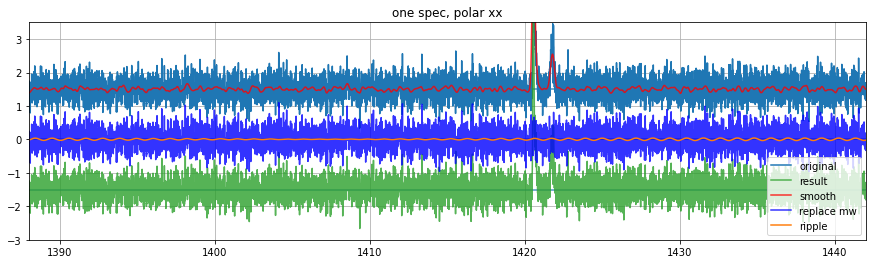

In [39]:
%matplotlib inline
offset = 1.5

tn = 4500
fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
ax.hlines([0,-offset, offset],freq[0],freq[-1],alpha = .8)
ax.plot(freq,data[tn] + offset,label='original')
ax.plot(freq,rmsw_data[tn] - offset,label='result',c='C2',alpha = .8)
ax.plot(freq,smooth1d(data[tn],method='gaussian', sigma=10) +offset,'r',label = 'smooth',alpha = .8)
ax.plot(freq,data_rep[tn],'b',label='replace mw',alpha = .8)
ax.plot(freq,sw_data[tn],c= 'C1',label='ripple')
ax.set_xlim(freq[0],freq[-1])
ax.set_ylim(-3,3.5) 
ax.grid();ax.legend();ax.set_title(f'one spec, polar xx')

平均10条谱线效果更明显，降低了很多

Text(0.5, 1.0, 'ten specs mean, polar xx')

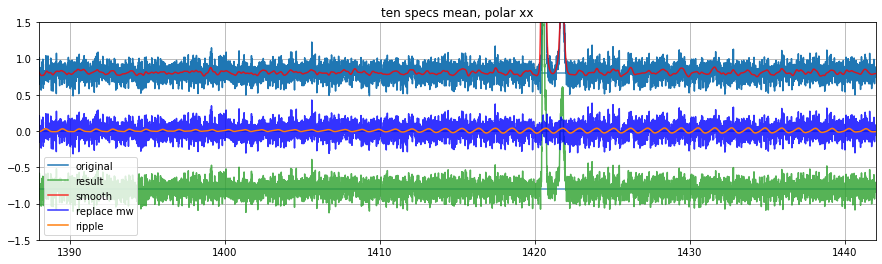

In [40]:
%matplotlib inline
offset = .8

fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
ax.hlines([0,-offset, offset],freq[0],freq[-1],alpha = .8)
ax.plot(freq,np.mean(data[tn-5:tn+5],axis=0)+offset,label='original')
ax.plot(freq,np.mean(rmsw_data[tn-5:tn+5],axis=0) -offset,label='result',c='C2',alpha = .8)
ax.plot(freq,np.mean(smooth1d(data[tn-5:tn+5],method='gaussian', sigma=10),axis=0) +offset,'r',label = 'smooth',alpha = .8)
ax.plot(freq,np.mean(data_rep[tn-5:tn+5],axis=0),'b',label='replace mw',alpha = .8)
ax.plot(freq,np.mean(sw_data[tn-5:tn+5],axis=0),c= 'C1',label='ripple')
ax.set_xlim(freq[0],freq[-1])
ax.set_ylim(-1.5,1.5) 
ax.grid();ax.legend();ax.set_title(f'ten specs mean, polar xx')

瀑布图效果

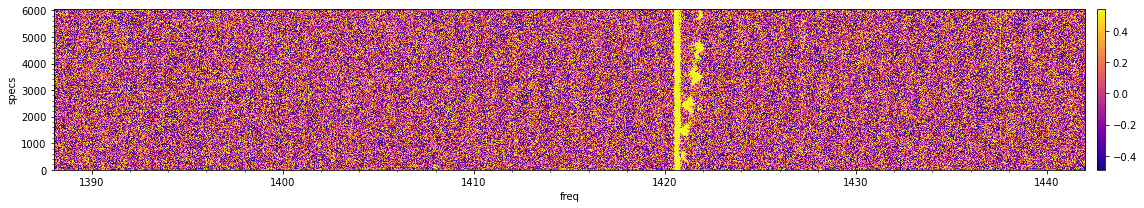

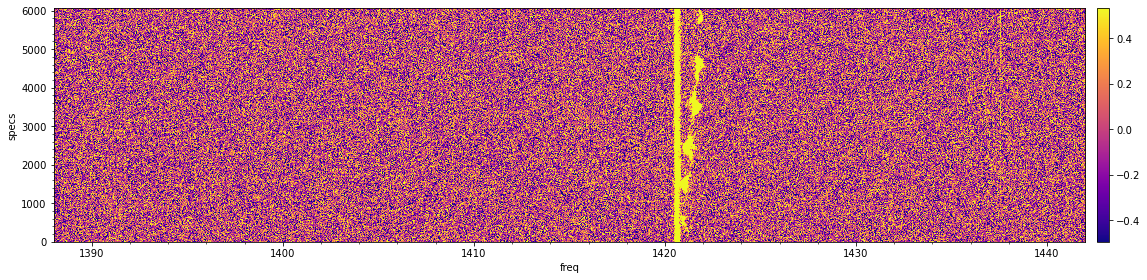

In [41]:
sub.plot_waterfall(data,per_vmin_max=.90,figsize=(18,3),cmap = 'plasma')
sub.plot_waterfall(rmsw_data,per_vmin_max=.90,figsize=(18,4),cmap = 'plasma')

# second iteration

第二次迭代,对上面输出的再进行平滑

In [42]:
sm_args = {}
sm_args['s_method_t'] = 'gaussian'
sm_args['s_sigma_t'] = 5
sm_args['s_method_freq'] = 'gaussian'
sm_args['s_sigma_freq'] = 3
sm_args['is_rfi'] = is_rfi
sm_args['is_on'] = is_on
data_find = do_smooth_onoff(rmsw_data, **sm_args)

sm_args = {}
sm_args['s_method_freq'] = 'gaussian'
sm_args['s_sigma_freq'] = 6
data_res = do_smooth_onoff(rmsw_data, **sm_args)

Smoothing t ...
Smoothing freq ...
Smoothing t ...
Smoothing freq ...
Smoothing freq ...


In [44]:
Lfreq = len(freq)
freq_d = int(Lfreq * 0.1)
freq_u = int(Lfreq * 0.9)

这是为了保存is_excluded的时候不要把两端的驻波标记太多

## replace

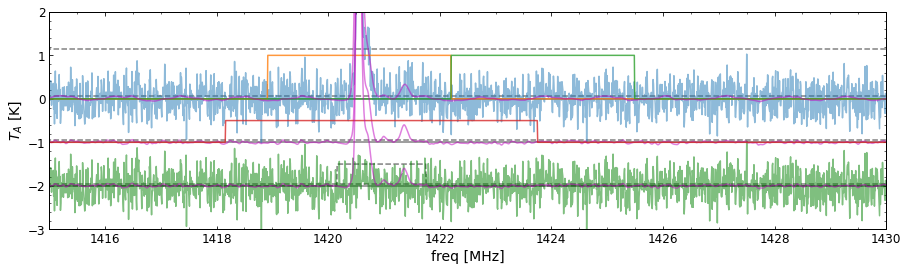

In [46]:
tn = 2000
spec = deepcopy(data[tn,:])
sm1 = data_trough[tn]
sm2 = data_find[tn]
sm3 = data_find[tn]
args = {}
args['times_thr'] = 4
args['times_s_thr'] = 3
args['times_s_thr2'] = 2
args['rfi_width_lim'] = 20
args['ext_sec'] = 30
args['ext_freq'] = 1.3
args['rms_sigma'] = 6
args['rms_frange'] = [1390,1400]
args['save_is_excluded'] = True
args['ex_step'] = 2

newspec, rep_from, rep_to, is_excluded = repalce_near_single(tn, freq, is_rfi, mw_use,
                                                sm1 = sm1, sm2 =sm2, sm3 = None, **args)
difuse = ((spec - newspec)!=0)

fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
ax.hlines(y=[0,-1,-2],xmax=freq[-1],xmin=freq[0],color='k',alpha=.5)
ax.plot(freq,spec,label='original',alpha = .5)
# ax.plot(freq,is_rfi[tn]*1.1,'r--',label='rfi',alpha = .5)
ax.plot(freq,rep_to,alpha=.8,label = 'replace area')
ax.plot(freq,rep_from,alpha=.8,label =  'copy from')
ax.plot(freq,sm1,'m',alpha=.5,label='smooth')
ax.plot(freq,difuse*.5 - 2,'k--',label =  'replaced part',alpha=.5,)
ax.plot(freq,newspec - 2,'g',alpha=.5,label =  'after replace')
ax.plot(freq,sm2 - 1,'m',alpha=.5)
ax.plot(freq,is_excluded*.5 - 1,alpha=.8,label =  'is_excluded')
ax.plot(freq,sm3 - 2,'m',alpha=.5)
from hifast.ripple.markRFI import real_rms, rms
RMS = rms(sm1,freq,rms_vrange=args['rms_frange'])
thr_s = RMS*args['times_s_thr']
RMS = rms(sm2,freq,rms_vrange=args['rms_frange'])
thr_s2 = RMS*args['times_s_thr2']

# ax.plot(freq,exceed_use*.6 - 1,alpha=.5)

RMS = rms(sm3,freq,rms_vrange=args['rms_frange'])
thr_s3 = RMS*args['times_s_thr']
ax.hlines(y=[thr_s,thr_s2 - 1, thr_s2-2],xmax=freq[-1],xmin=freq[0],color='k', label = 'thr_s',linestyle='dashed',alpha=.5)

RMS = real_rms(spec,freq,sigma=args['rms_sigma'],rms_vrange=args['rms_frange'])
thr = RMS*args['times_thr']
ax.hlines(y=[thr],xmax=freq[-1],xmin=freq[0],color='k',label = 'thr', linestyle='dashed',alpha=.5)
line_set(ax,xlabel='freq [MHz]',ylabel='$T_A$ [K]',xlim=[1415,1430],ylim=[-3,2],legend=False,title=None)

In [47]:
rep_args

{'rms_sigma': 6,
 'rms_frange': [1405, 1410],
 'times_thr': 4,
 'times_s_thr': 3,
 'rfi_width_lim': 20,
 'ext_sec': 20,
 'ext_freq': 1.3}

使用此参数再replace，FFT

In [48]:
rep_args['times_s_thr2'] = 2
rep_args['save_is_excluded'] = True
data_rep2, is_excluded = replace_rfi(data, freq, time_rfi=is_rfi, method='near_ripple', 
                                 data_find = data_find, data_trough = data_trough, data_restrict = data_res, **rep_args)

INFO: Replace RFI with near_ripple method ... [hifast.ripple.sw_fft]


CPU 0: 100%|██████████| 6057/6057 [00:10<00:00, 591.67it/s]


In [49]:
sw_data_off = fit_sw_fft(data_rep2[~is_on], freq, nproc=10,  **fft_args_off)
sw_data_on = fit_sw_fft(data_rep2[is_on], freq, nproc=10,  **fft_args_on)

sw_data2 = np.zeros_like(data) # 驻波
sw_data2[is_on] = sw_data_on
sw_data2[~is_on] = sw_data_off

rmsw_data2 = data - sw_data2 # remove standing waves之后的结果

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100


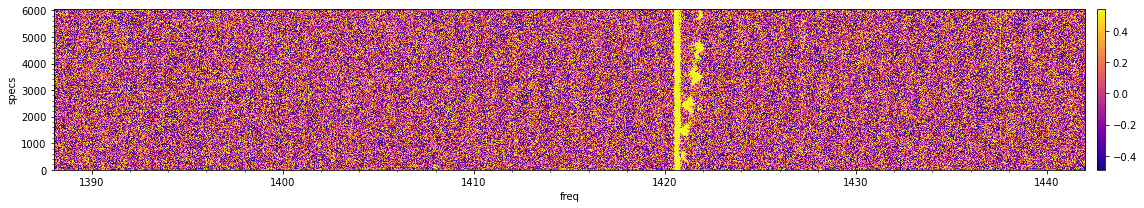

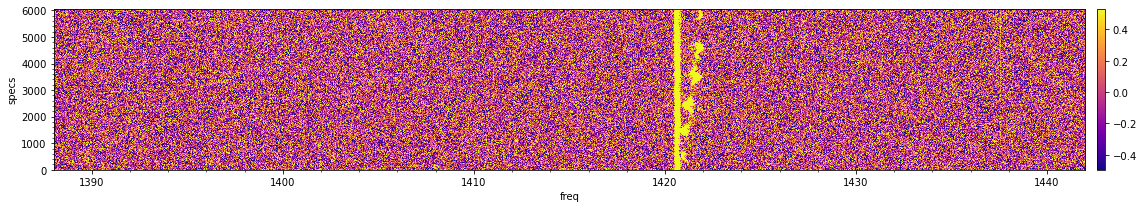

In [50]:
%matplotlib inline
sub.plot_waterfall(data,per_vmin_max=.90,figsize=(18,3),cmap = 'plasma')
sub.plot_waterfall(rmsw_data2,per_vmin_max=.90,figsize=(18,3),cmap = 'plasma')

迭代的区别其实很小

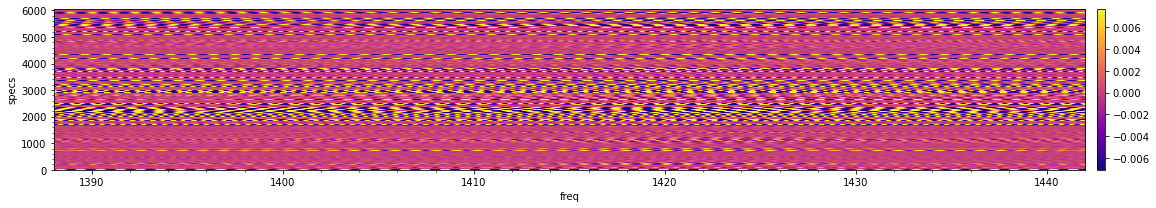

In [51]:
sub.plot_waterfall(rmsw_data2 - rmsw_data,per_vmin_max=.90,figsize=(18,3),cmap = 'plasma')

还得到了一个mask

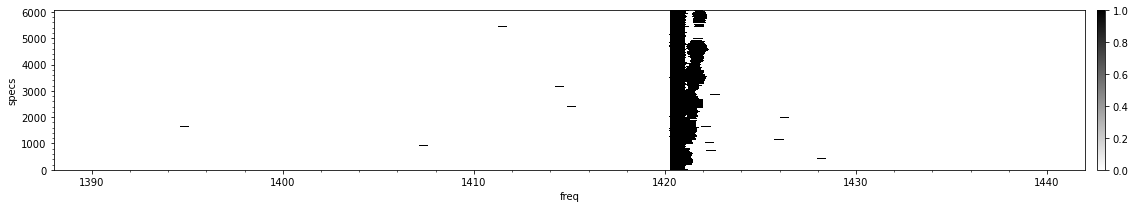

In [52]:
sub.plot_waterfall(is_excluded,figsize=(18,3),cmap = 'gray_r')

# Run .ini

In [4]:
subname = '/data/inspur_disk01/userdir/xuc/FAST/M33/new_21/OTF_h/rfi/M33_OTF_1_MultiBeamOTF-M01_W-20210731-specs_T-bld-rfi.hdf5'

In [ ]:
!python -m hifast.sw $subname -c ./conf/S4-sw.ini -f --outdir ./data_S/

In [53]:
from hifast.ripple.util import Read_hdf5, Args
name = './data_S/M33_OTF_1_MultiBeamOTF-M01_W-20210731-specs_T-bld-rfi-sw.hdf5'
f = Read_hdf5(Args(name))

outdir: ./data_S


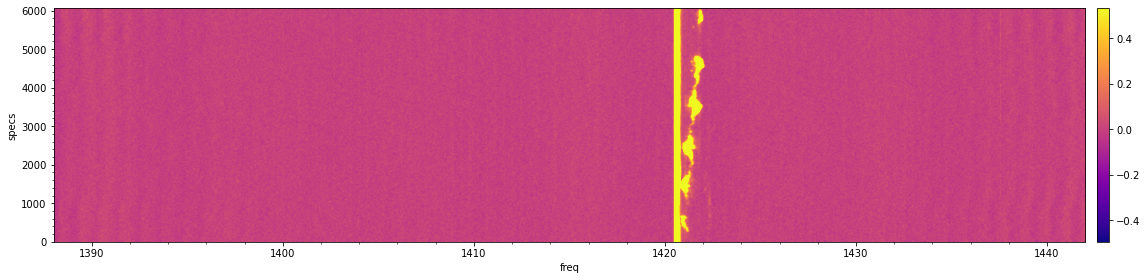

In [54]:
T0 = f.get_data(polar='xx')
f.plot_waterfall(T0, per_vmin_max=.90,figsize=(18,4),cmap = 'plasma',interp_method='gaussian')

嗯，确实去除了驻波。但是注意两边会变差，因为对于DFT，两边是截断。